In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE

In [173]:
root_path = "/home/stefan/ioai-prep/kits/gaia/planet-x"

seed = 42

# Data

In [174]:
df = pd.read_csv(f"{root_path}/train_data.csv")
features = df.iloc[:, :15]
predictions = df.iloc[:, 15:]

predictions.head()

,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,...,model_990,model_991,model_992,model_993,model_994,model_995,model_996,model_997,model_998,model_999
0,-0.220005,-1.246956,-1.170237,-0.678676,0.954930,-0.600599,0.847153,-2.401707,-1.181563,1.324786,...,1.158999,1.811489,-1.399001,0.283525,0.155327,-0.115795,0.701612,0.540903,-0.187688,1.688532
1,-0.370413,0.312248,0.544165,-0.495395,0.735287,-0.281372,-0.374829,0.148348,0.644211,-0.155793,...,-1.762717,-0.466980,0.862179,-0.356308,-1.320454,-0.260318,0.907918,0.035840,-0.610121,0.053372
2,-1.846912,1.223085,1.958558,0.519197,-0.350826,0.106240,-0.234498,-0.652043,1.736163,0.100157,...,-0.653911,0.508785,-0.004793,0.327369,0.309892,-0.739826,-0.200575,-0.901790,-0.953651,-0.260904
3,0.775243,1.644579,0.476759,-0.183464,0.499240,1.016460,0.683616,0.383798,1.139295,-0.541624,...,-1.935910,-2.662299,1.311143,1.272996,-2.466279,0.527003,-0.807965,0.329840,-0.963367,-0.453477
4,0.213452,1.189588,0.415106,-0.763884,-1.276845,1.960262,-1.067856,-0.583060,1.675255,0.202117,...,0.721824,1.033883,-0.785103,0.371600,-0.663562,-0.836546,0.643650,-1.493408,-0.284494,-0.202831


# Detect models

In [ ]:
model = LinearRegression()
# X = features, y = predictions, 1000 outputs
model.fit(features, predictions)
coefficients = model.coef_

coefficients.shape

(1000, 15)

which models have the closest, most similar, coefficients?

In [176]:
scaler = StandardScaler()
coefs_scaled = scaler.fit_transform(coefficients)

In [177]:
nn = NearestNeighbors(n_neighbors=5)
nn.fit(coefs_scaled)
distances, indices = nn.kneighbors(coefs_scaled)

In [ ]:
mean_distances = distances.mean(axis=1)  # (1000,)
best_model_idx = np.argmin(mean_distances)
top5 = sorted(indices[best_model_idx])

top5

[np.int64(11), np.int64(181), np.int64(356), np.int64(483), np.int64(848)]

<Axes: >

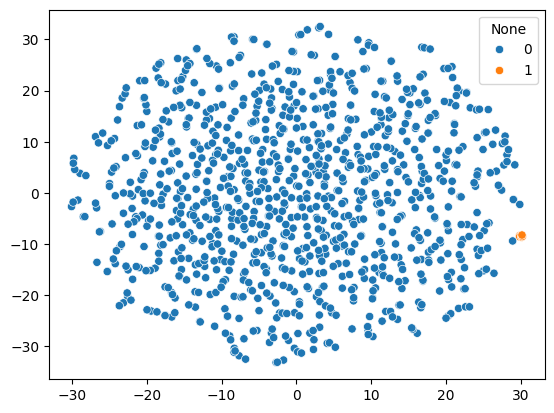

In [183]:
tsne = TSNE(random_state=seed)
xy = tsne.fit_transform(coefs_scaled)

df_coef = pd.Series([0] * len(coefs_scaled))
df_coef.iloc[indices[best_model_idx]] = 1

# all 5 are very close to each other
sns.scatterplot(x=xy[:, 0], y=xy[:, 1], hue=df_coef)

# Submission

In [180]:
answer_str = ",".join(map(str, top5))

submission = pd.DataFrame(
    {"subtaskID": [1], "datapointID": [0], "answer": [answer_str]}
)

In [181]:
submission.head()

,subtaskID,datapointID,answer
0,1,0,"11,181,356,483,848"


In [182]:
submission.to_csv(f"{root_path}/submission.csv", index=False)